<a href="https://colab.research.google.com/github/arifsl65/myfirstgit/blob/main/Stock_Api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
from plotnine import *
import yfinance as yf
from datetime import date
import requests
import requests
import json
from pprint import pprint




%matplotlib inline


In [23]:

# # Replace 'OX4FBEKLFOON3WQD' with your actual Alpha Vantage API key
# api_key = 'OX4FBEKLFOON3WQD'
# url = f'https://www.alphavantage.co/query?function=OVERVIEW&symbol=MSFT&apikey{api_key}'

# # Make the API request
# response = requests.get(url)

# # Check if the request was successful (status code 200)
# if response.status_code == 200:
#     # Parse the JSON response
#     data = response.json()

#     # Check if the 'bestMatches' key is present in the response
#     if 'bestMatches' in data:
#         # Convert the 'bestMatches' data to a DataFrame
#         df = pd.DataFrame(data['bestMatches'])

#         # Print the DataFrame
#         print(df)
#     else:
#         print("No matching symbols found.")
# else:
#     # Print an error message if the request was not successful
#     print(f"Error: {response.status_code} - {response.text}")


Company Info

In [24]:


api_key = 'OX4FBEKLFOON3WQD'
ticker = 'MSFT'

url = f'https://www.alphavantage.co/query?function=OVERVIEW&symbol={ticker}&apikey={api_key}'
r = requests.get(url)
data = r.json()

Company_info = json.loads(json.dumps(data))

print(Company_info)
pprint(data)



{'Symbol': 'MSFT', 'AssetType': 'Common Stock', 'Name': 'Microsoft Corporation', 'Description': "Microsoft Corporation is an American multinational technology company which produces computer software, consumer electronics, personal computers, and related services. Its best known software products are the Microsoft Windows line of operating systems, the Microsoft Office suite, and the Internet Explorer and Edge web browsers. Its flagship hardware products are the Xbox video game consoles and the Microsoft Surface lineup of touchscreen personal computers. Microsoft ranked No. 21 in the 2020 Fortune 500 rankings of the largest United States corporations by total revenue; it was the world's largest software maker by revenue as of 2016. It is considered one of the Big Five companies in the U.S. information technology industry, along with Google, Apple, Amazon, and Facebook.", 'CIK': '789019', 'Exchange': 'NASDAQ', 'Currency': 'USD', 'Country': 'USA', 'Sector': 'TECHNOLOGY', 'Industry': 'SER

In [25]:
msft = yf.Ticker("MSFT")

History

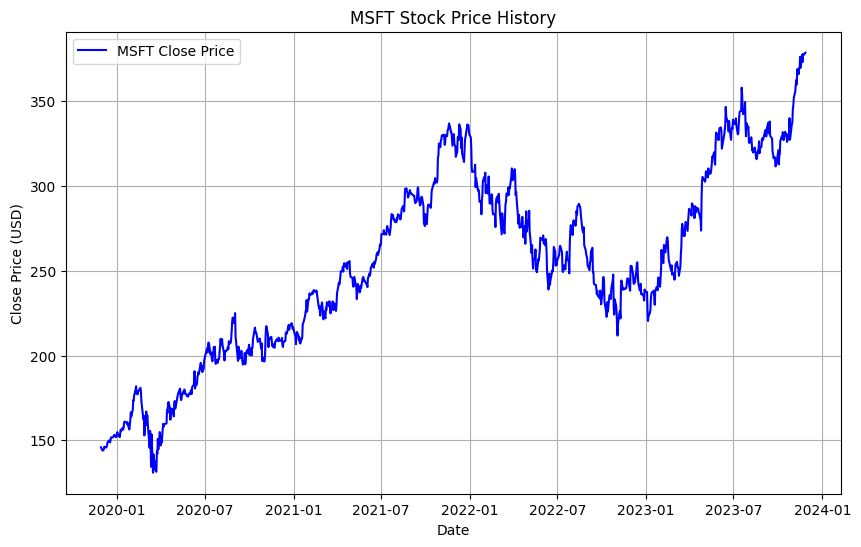

In [26]:


# get historical market data
hist =  yf.Ticker("MSFT").history(period='4y')


plt.figure(figsize=(10, 6))
plt.plot(hist.index, hist['Close'], label='MSFT Close Price', color='blue')
plt.title('MSFT Stock Price History')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()



In [27]:
# hist.iloc[0].Open

In [28]:
# meta = print(msft.history_metadata)

In [29]:
# msft.actions


Plot Divident

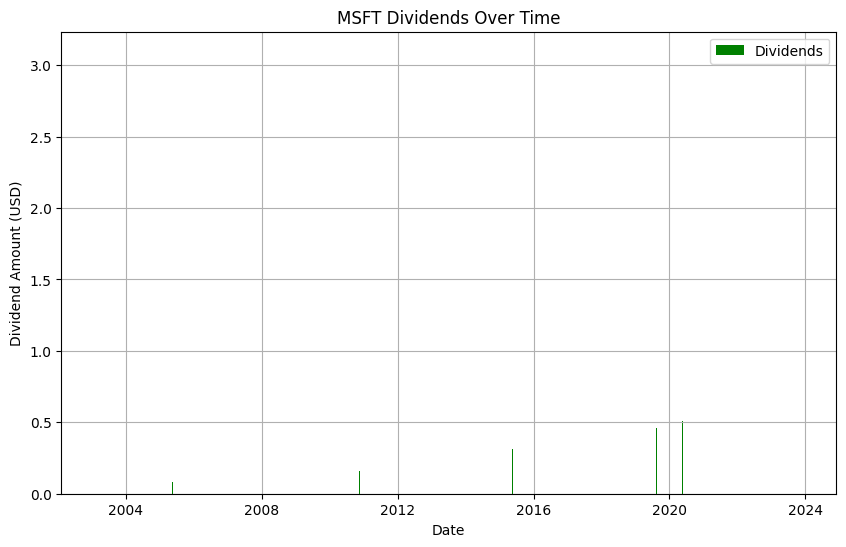

In [30]:

# Get corporate actions data
actions = msft.actions

# Filter relevant columns for visualization
dividends = actions[actions['Dividends'] > 0]
splits = actions[actions['Stock Splits'] > 0]

# Plotting dividends
plt.figure(figsize=(10, 6))
plt.bar(dividends.index, dividends['Dividends'], label='Dividends', color='green')
plt.title('MSFT Dividends Over Time')
plt.xlabel('Date')
plt.ylabel('Dividend Amount (USD)')
plt.legend()
plt.grid(True)
plt.show()

Net Profit Plot

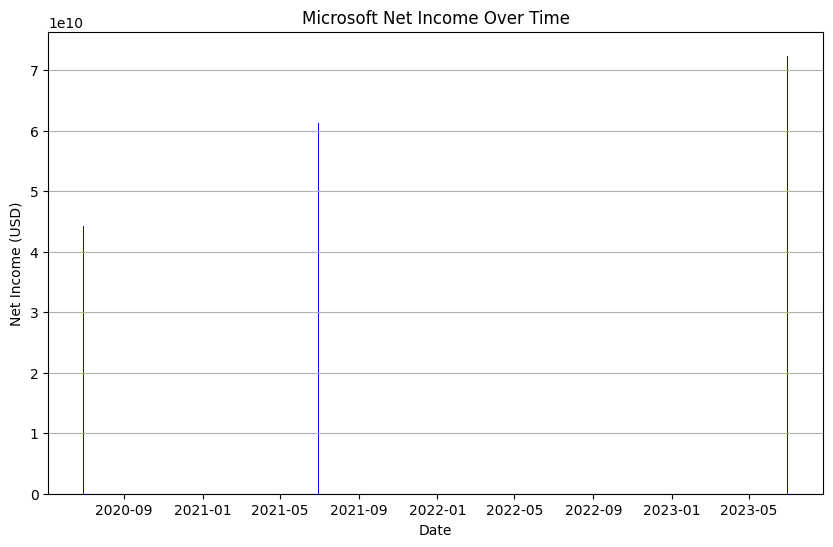

In [31]:
msft.income_stmt
income_stmt= msft.income_stmt


df_income_statement = pd.DataFrame(income_stmt)

net_income_row = df_income_statement.loc['Net Income']

# Convert the data to a pandas Series
net_income_series = pd.Series(net_income_row)

# Plot 'Net Income' over time
plt.figure(figsize=(10, 6))
plt.bar(net_income_series.index, net_income_series, color='blue')
plt.title('Microsoft Net Income Over Time')
plt.xlabel('Date')
plt.ylabel('Net Income (USD)')
plt.grid(axis='y')
plt.show()




In [32]:
msft.major_holders


,0,1
0,0.05%,% of Shares Held by All Insider
1,73.21%,% of Shares Held by Institutions
2,73.25%,% of Float Held by Institutions
3,6255,Number of Institutions Holding Shares


institutional holders data

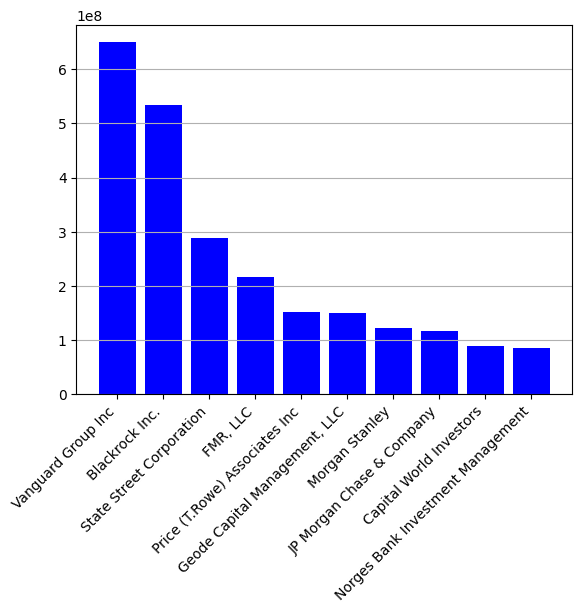

In [33]:
# Get institutional holders data
institutional_holders = msft.institutional_holders

institutional_holders.head()
plt.bar(institutional_holders.Holder,institutional_holders.Shares, color='blue')

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y')
plt.show()


institutional holders pie Chart

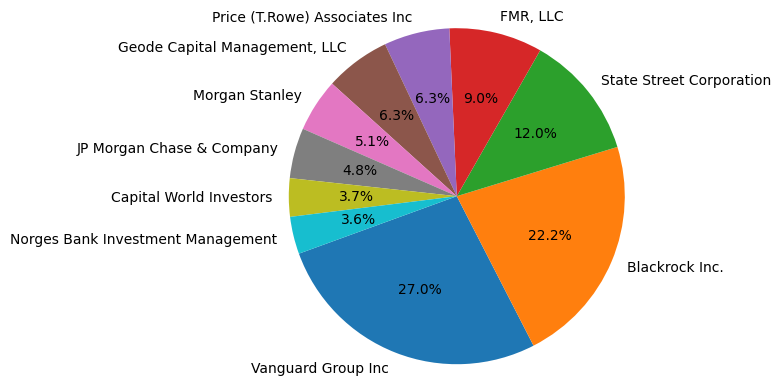

In [34]:

# Assuming institutional_holders is your DataFrame
plt.pie(institutional_holders['Shares'], labels=institutional_holders['Holder'], autopct='%1.1f%%', startangle=200)
plt.axis('equal')  # Equal aspect ratio ensures that the pie chart is circular.

plt.show()


Mutual fund Holder

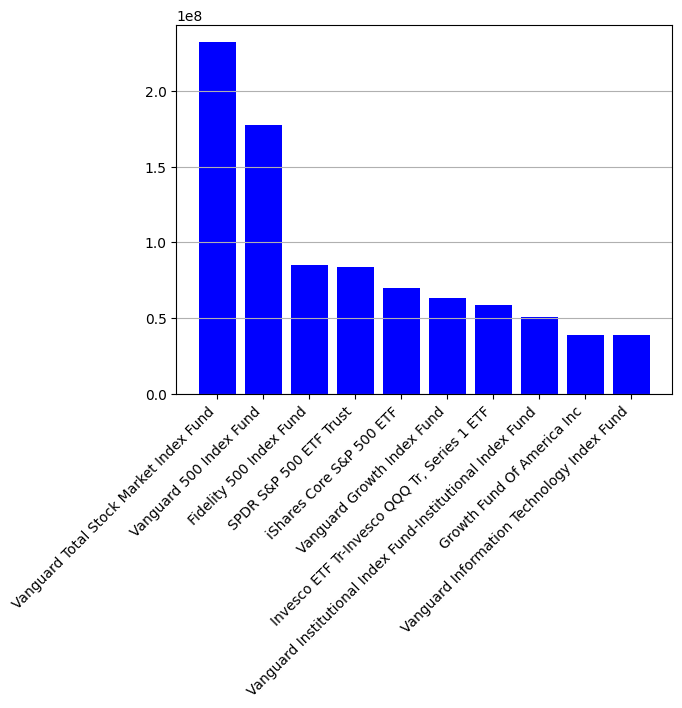

In [35]:
msft.mutualfund_holders
plt.bar(msft.mutualfund_holders.Holder,msft.mutualfund_holders.Shares, color='blue')
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y')
plt.show()


Mutual fund Holder Pie chart

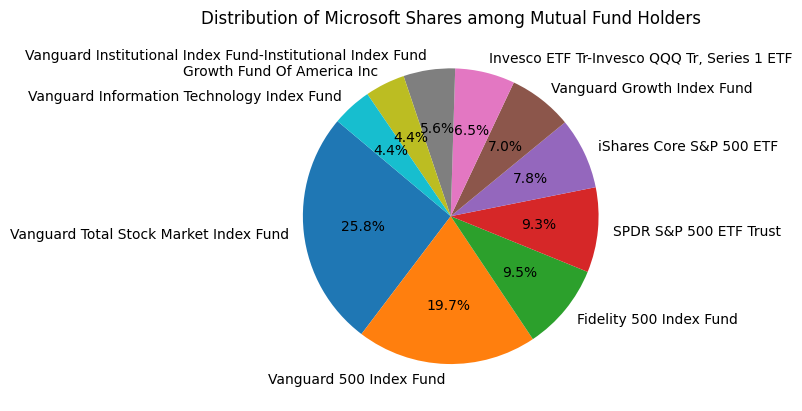

In [36]:
plt.pie(msft.mutualfund_holders.Shares, labels=msft.mutualfund_holders.Holder, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Microsoft Shares among Mutual Fund Holders')
plt.show()

News

In [37]:
newsData = pd.DataFrame(msft.news)

print(newsData[['title']])




                                               title
0    Microsoft Needs a Better Seat at OpenAI’s Table
1  Microsoft Continues to Invest Heavily in AI --...
2  Dow Jones Futures: Fed Chair Powell Speech Loo...
3  Market Today: Shopify Soars on Black Friday Su...
4  Magnificent Seven Stocks: Microsoft Ignites AI...
5  This week in AI: The OpenAI debacle shows the ...
6  These 3 Dow Jones Stocks Are Blazing Hot. Are ...
7  This Popular Tech Sector ETF Is Foreshadowing ...


Chart of Today

[*********************100%%**********************]  1 of 1 completed


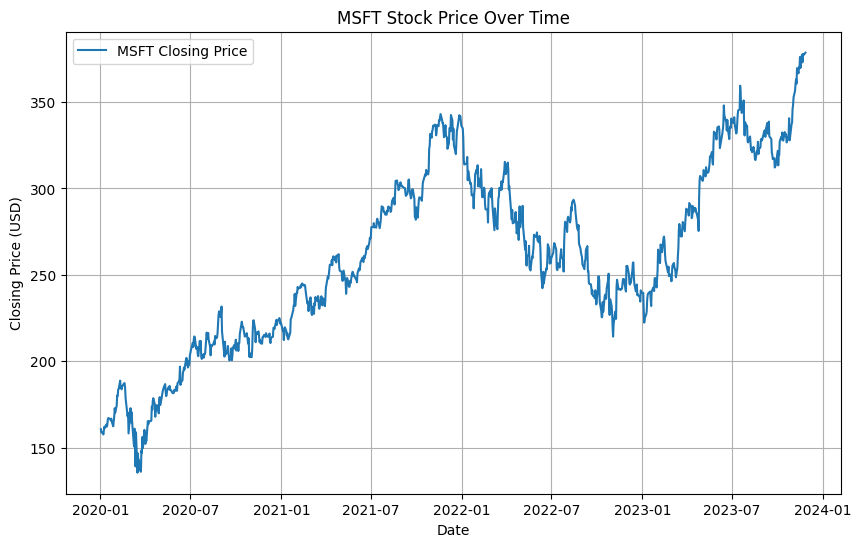

In [38]:

market = "MSFT"


# Get today's date
end_date = date.today()

# Download data with start date "2020-01-01" and end date as today
df = yf.download(market, group_by="ticker", start="2020-01-01", end=end_date)

plt.figure(figsize=(10, 6))
plt.plot(df['Close'], label=f"{market} Closing Price")
plt.title(f"{market} Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)
plt.show()